                              #### COVID-19 Death Prediction ML Project ###

In [26]:
# 1. IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

import xgboost as xgb

import warnings
warnings.filterwarnings("ignore")

In [27]:
# 2. LOAD DATASET

df = pd.read_csv("/Users/rubys/Pragra-Python-AI-ML-Learning/Provisional_COVID-19_Deaths_by_Sex_and_Age_20260602.csv")

print("Original Shape:", df.shape)
print(df.head())

Original Shape: (137700, 16)
   Data As Of  Start Date    End Date     Group  Year  Month          State  \
0  09/27/2023  01/01/2020  09/23/2023  By Total   NaN    NaN  United States   
1  09/27/2023  01/01/2020  09/23/2023  By Total   NaN    NaN  United States   
2  09/27/2023  01/01/2020  09/23/2023  By Total   NaN    NaN  United States   
3  09/27/2023  01/01/2020  09/23/2023  By Total   NaN    NaN  United States   
4  09/27/2023  01/01/2020  09/23/2023  By Total   NaN    NaN  United States   

         Sex     Age Group COVID-19 Deaths Total Deaths Pneumonia Deaths  \
0  All Sexes      All Ages       1,146,774   12,303,399        1,162,844   
1  All Sexes  Under 1 year             519       73,213            1,056   
2  All Sexes    0-17 years           1,696      130,970            2,961   
3  All Sexes     1-4 years             285       14,299              692   
4  All Sexes    5-14 years             509       22,008              818   

  Pneumonia and COVID-19 Deaths Influen

In [28]:
# 3. DATA CLEANING

# Replace missing-like values
df.replace(["Suppressed", "NA", "NaN", ""], np.nan, inplace=True)

# Remove commas from numeric values
for col in df.columns:
    df[col] = df[col].astype(str).str.replace(",", "")

# Numeric columns
num_cols = [
    "COVID-19 Deaths",
    "Total Deaths",
    "Pneumonia Deaths",
    "Influenza Deaths"
]

# Convert numeric columns
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Target column
target = "COVID-19 Deaths"

# Remove missing target rows
df = df.dropna(subset=[target])

print("After Cleaning Shape:", df.shape)

After Cleaning Shape: (98270, 16)


In [29]:
# 4. OUTLIER HANDLING

Q1 = df[target].quantile(0.25)
Q3 = df[target].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df[target] >= lower) & (df[target] <= upper)]

print("After Outlier Removal:", df.shape)


After Outlier Removal: (83353, 16)


In [30]:
# 5. EXPLORATORY DATA ANALYSIS

print("\n===== DATA INFO =====")
print(df.info())

print("\n===== SUMMARY STATS =====")
print(df[target].describe())

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())



===== DATA INFO =====
<class 'pandas.DataFrame'>
Index: 83353 entries, 52 to 137696
Data columns (total 16 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Data As Of                                83353 non-null  str    
 1   Start Date                                83353 non-null  str    
 2   End Date                                  83353 non-null  str    
 3   Group                                     83353 non-null  str    
 4   Year                                      82588 non-null  str    
 5   Month                                     78062 non-null  str    
 6   State                                     83353 non-null  str    
 7   Sex                                       83353 non-null  str    
 8   Age Group                                 83353 non-null  str    
 9   COVID-19 Deaths                           83353 non-null  float64
 10  Total Deaths             

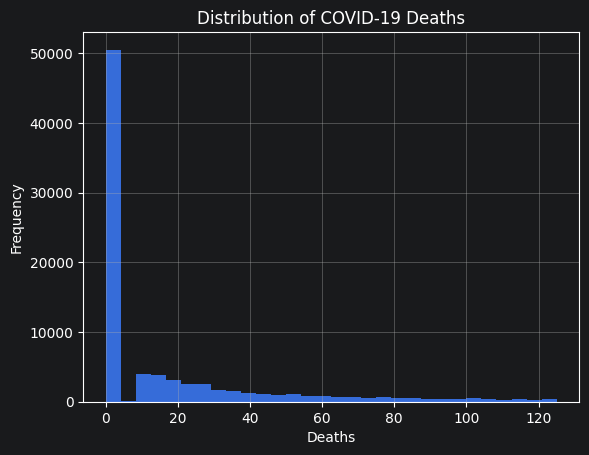

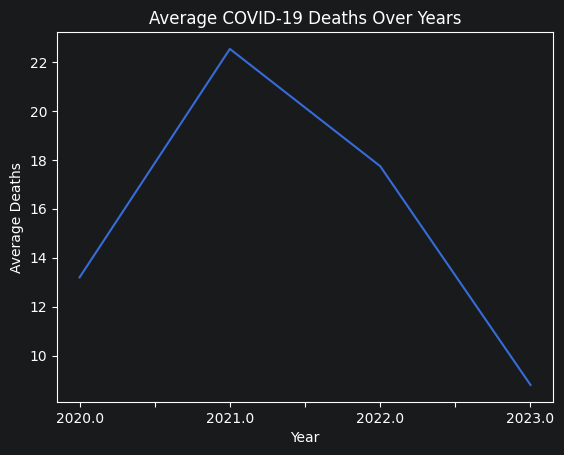

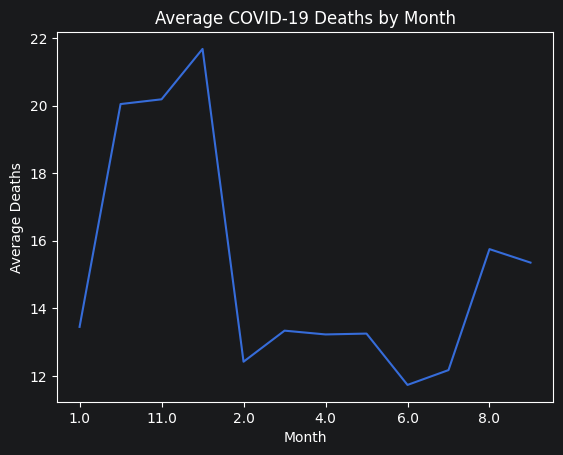

<Figure size 1000x600 with 0 Axes>

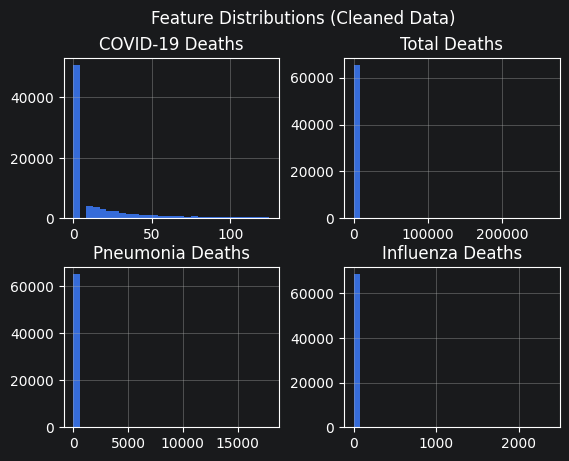

In [31]:
# 6. DATA VISUALIZATION

# 1. Distribution of target variable
plt.figure()
df[target].hist(bins=30)
plt.title("Distribution of COVID-19 Deaths")
plt.xlabel("Deaths")
plt.ylabel("Frequency")
plt.show()


# 2. Year-wise trend
plt.figure()
df.groupby("Year")[target].mean().plot()
plt.title("Average COVID-19 Deaths Over Years")
plt.xlabel("Year")
plt.ylabel("Average Deaths")
plt.show()


# 3. Month-wise trend (seasonality)
plt.figure()
df.groupby("Month")[target].mean().plot()
plt.title("Average COVID-19 Deaths by Month")
plt.xlabel("Month")
plt.ylabel("Average Deaths")
plt.show()


# 4. Feature distributions (after cleaning — NOT outlier detection)
plt.figure(figsize=(10,6))

df[[
    "COVID-19 Deaths",
    "Total Deaths",
    "Pneumonia Deaths",
    "Influenza Deaths"
]].hist(bins=30)

plt.suptitle("Feature Distributions (Cleaned Data)")
plt.show()


In [32]:
# 7. FEATURE ENGINEERING

# Convert Year and Month
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")

# Seasonality features
df["month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)

# Age encoding
age_map = {
    "0-17 years": 0,
    "18-29 years": 1,
    "30-49 years": 2,
    "50-64 years": 3,
    "65-74 years": 4,
    "75-84 years": 5,
    "85 years and over": 6
}

df["age_encoded"] = df["Age Group"].map(age_map)


In [33]:
# 8. DROP UNUSED COLUMNS

drop_cols = ["Data As Of", "Start Date", "End Date", "Footnote"]

df = df.drop(columns=[c for c in drop_cols if c in df.columns])


In [34]:
# 9. PREPARE FEATURES & TARGET
X = df.drop(columns=[target], errors="ignore")
y = df[target]

# Encode categorical columns
le = LabelEncoder()

for col in X.select_dtypes(include="object").columns:
    X[col] = le.fit_transform(X[col].astype(str))

# Handle missing values
imputer = SimpleImputer(strategy="median")

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

In [35]:
# 10. TIME-BASED TRAIN TEST SPLIT

df_sorted = df.sort_values(by=["Year", "Month"])

X = df_sorted.drop(columns=[target], errors="ignore")
y = df_sorted[target]

# Encode categorical columns again
for col in X.select_dtypes(include="object").columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# Handle missing values again
X = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(X),
    columns=X.columns
)

# 80-20 split
split = int(len(df_sorted) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [ ]:
# 11. MODEL TRAINING

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

In [37]:
# 12. MODEL EVALUATION

def evaluate(model, name):

    pred = model.predict(X_test)

    print(f"\n===== {name} =====")
    print("MAE:", mean_absolute_error(y_test, pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
    print("R2:", r2_score(y_test, pred))


evaluate(lr, "Linear Regression")
evaluate(xgb_model, "XGBoost")


===== Linear Regression =====
MAE: 12.46208277778866
RMSE: 16.973462909614344
R2: 0.37311484182869636

===== XGBoost =====
MAE: 1.6137378736594836
RMSE: 5.086965766855255
R2: 0.9436926995412813


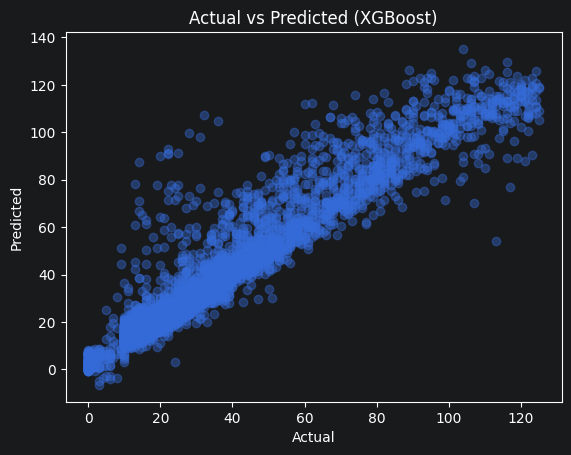

In [38]:
# 13. ACTUAL VS PREDICTED

pred = xgb_model.predict(X_test)

plt.figure()

plt.scatter(y_test, pred, alpha=0.4)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted (XGBoost)")

plt.show()


In [39]:
# 14. FEATURE IMPORTANCE

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 10 Features:")
print(importance.head(10))



Top 10 Features:
                                     Feature  Importance
7                           Pneumonia Deaths    0.495409
8              Pneumonia and COVID-19 Deaths    0.291841
10  Pneumonia, Influenza, or COVID-19 Deaths    0.098075
1                                       Year    0.026689
9                           Influenza Deaths    0.024849
6                               Total Deaths    0.017877
2                                      Month    0.013653
5                                  Age Group    0.010439
3                                      State    0.004348
12                                 month_cos    0.004309


In [40]:
# 15. FINAL MODEL SCORES

results = {
    "Linear Regression": lr.score(X_test, y_test),
    "XGBoost": xgb_model.score(X_test, y_test)
}

print("\n===== FINAL MODEL SCORES =====")
print(results)


===== FINAL MODEL SCORES =====
{'Linear Regression': 0.37311484182869636, 'XGBoost': 0.9436926995412813}
